# Clothing Condition Classifier — Project Summary

**BYU CS 474 Final Project**

This notebook presents the results of every experiment in one place. No models are re-trained or re-evaluated here — all numbers are loaded from saved outputs. The goal is to tell the story of the project: what we tried, what worked, what didn't, and why.

---

## Project at a Glance

**Task:** Predict the condition grade (1–5) of second-hand clothing from front/back photos.  
**Secondary task:** Detect fraud — items where the seller inflates the condition score.  
**Dataset:** ~32K items from 3 inspection stations, each with front photo, back photo, and metadata (condition, stains, holes, pilling).  
**Architecture:** Dual-stream EfficientNet-B2 with shared backbone, two-phase transfer learning.

### Experiments (chronological)

| # | Experiment | Key Question |
|---|---|---|
| 1 | **V1 Baseline** | Can a CNN predict clothing condition at all? |
| 2 | **V2 Multi-task + Ordinal Loss** | Does ordinal loss + auxiliary heads improve condition prediction? |
| 3 | **Error Analysis** | Where does the model fail and why? |
| 4 | **Station Experiment** | Is the bottleneck model capacity or label quality? |
| 5 | **Fraud Pipeline (V2)** | Can we detect fraudulent condition claims? |
| 6 | **Vision-as-Auditor** | Can a fine-tuned model act as an independent fraud checker? |

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

ROOT = Path("..").resolve()
FIGURES = ROOT / "report" / "figures"
RESULTS = ROOT / "results"
CKPT_V1 = ROOT / "checkpoints"
CKPT_AUDITOR = ROOT / "checkpoints_auditor"

---
## 1. V1 Baseline — "Can a CNN learn clothing condition?"

**Setup:** Dual-stream EfficientNet-B2, CrossEntropyLoss, two-phase freeze/unfreeze, mixup, label smoothing.  
**Training:** 10 epochs (early stopped from 15-epoch budget).

**Verdict: Yes, but barely.** 45% accuracy on a 5-class task (vs. 20% random) shows the model learns real visual features, but treating condition grades as unordered categories wastes information — predicting grade 1 when the truth is 5 costs the same as predicting 4.

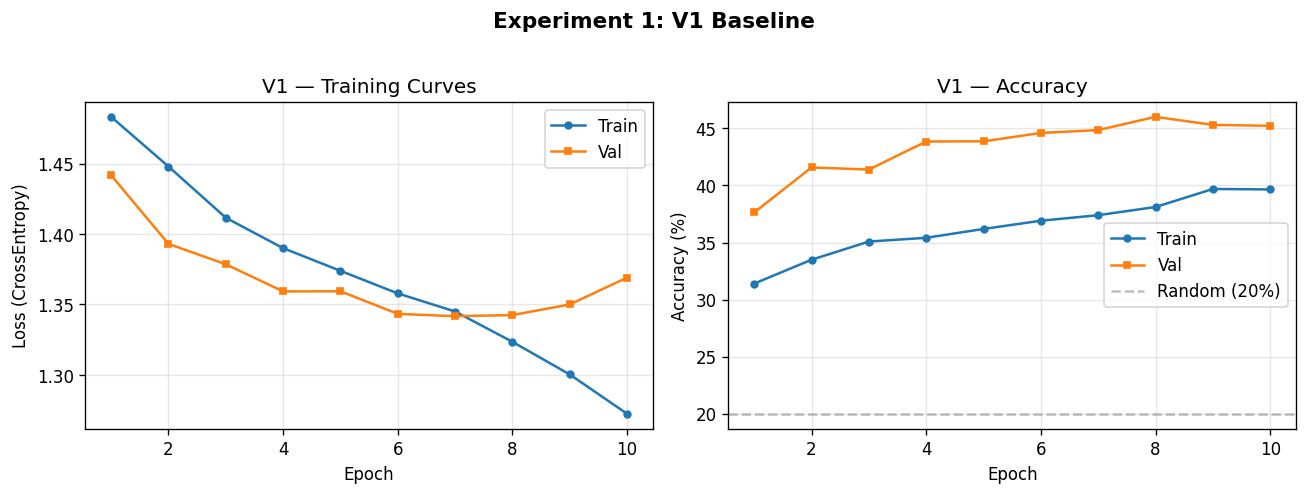

Best val accuracy: 46.0%  (epoch 7)
Best val loss:     1.3417


In [2]:
# Load V1 training history
with open(CKPT_V1 / "training_history.json") as f:
    v1_hist = json.load(f)

epochs_v1 = list(range(1, len(v1_hist["val_acc"]) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs_v1, v1_hist["train_loss"], "o-", label="Train", markersize=4)
ax1.plot(epochs_v1, v1_hist["val_loss"], "s-", label="Val", markersize=4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (CrossEntropy)")
ax1.set_title("V1 — Training Curves")
ax1.legend()

ax2.plot(epochs_v1, [a * 100 for a in v1_hist["train_acc"]], "o-", label="Train", markersize=4)
ax2.plot(epochs_v1, [a * 100 for a in v1_hist["val_acc"]], "s-", label="Val", markersize=4)
ax2.axhline(20, color="gray", ls="--", alpha=0.5, label="Random (20%)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("V1 — Accuracy")
ax2.legend()

fig.suptitle("Experiment 1: V1 Baseline", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Best val accuracy: {max(v1_hist['val_acc'])*100:.1f}%  (epoch {np.argmin(v1_hist['val_loss'])+1})")
print(f"Best val loss:     {min(v1_hist['val_loss']):.4f}")

---
## 2. V2 Multi-Task + Ordinal Loss — "Treat grades as ordered, add defect heads"

**Changes from V1:**
- Replaced CrossEntropy with **ordinal KL-divergence soft-label loss** (σ=1.0) — penalizes distant errors more
- Added **3 auxiliary heads** (stains, holes, pilling) to force defect-aware representations
- Same backbone, same training strategy

**Verdict: The right trade-off.** Raw accuracy dropped slightly (45% → 41%), but the model makes far fewer catastrophic errors. MAE of 0.81 means the average prediction is less than one grade off, and 82% of predictions land within ±1 grade.

In [3]:
# V2 results (from Results_v2.md — no separate history JSON, values hardcoded from the writeup)
v2_metrics = {
    "Condition Accuracy": 40.6,
    "Condition MAE": 0.812,
    "Within ±1 Grade": 82.4,
    "Stains Accuracy": 63.7,
    "Holes Accuracy": 75.6,
    "Pilling Accuracy": 58.0,
}

# Side-by-side V1 vs V2
comparison = pd.DataFrame({
    "Metric": ["Condition Accuracy", "Condition MAE", "Within ±1 Grade", "Within ±2 Grades", "Catastrophic (±3+)"],
    "V1 Baseline": ["45.0%", "—", "—", "—", "—"],
    "V2 (Ordinal + Multi-task)": ["40.6%", "0.812", "82.4%", "96.1%", "3.9%"],
    "Random Baseline": ["20.0%", "1.52", "~52%", "~76%", "~24%"],
})
print("V1 → V2: Condition Prediction")
print("=" * 70)
display(comparison.style.hide(axis="index"))

V1 → V2: Condition Prediction


Metric,V1 Baseline,V2 (Ordinal + Multi-task),Random Baseline
Condition Accuracy,45.0%,40.6%,20.0%
Condition MAE,—,0.812,1.52
Within ±1 Grade,—,82.4%,~52%
Within ±2 Grades,—,96.1%,~76%
Catastrophic (±3+),—,3.9%,~24%


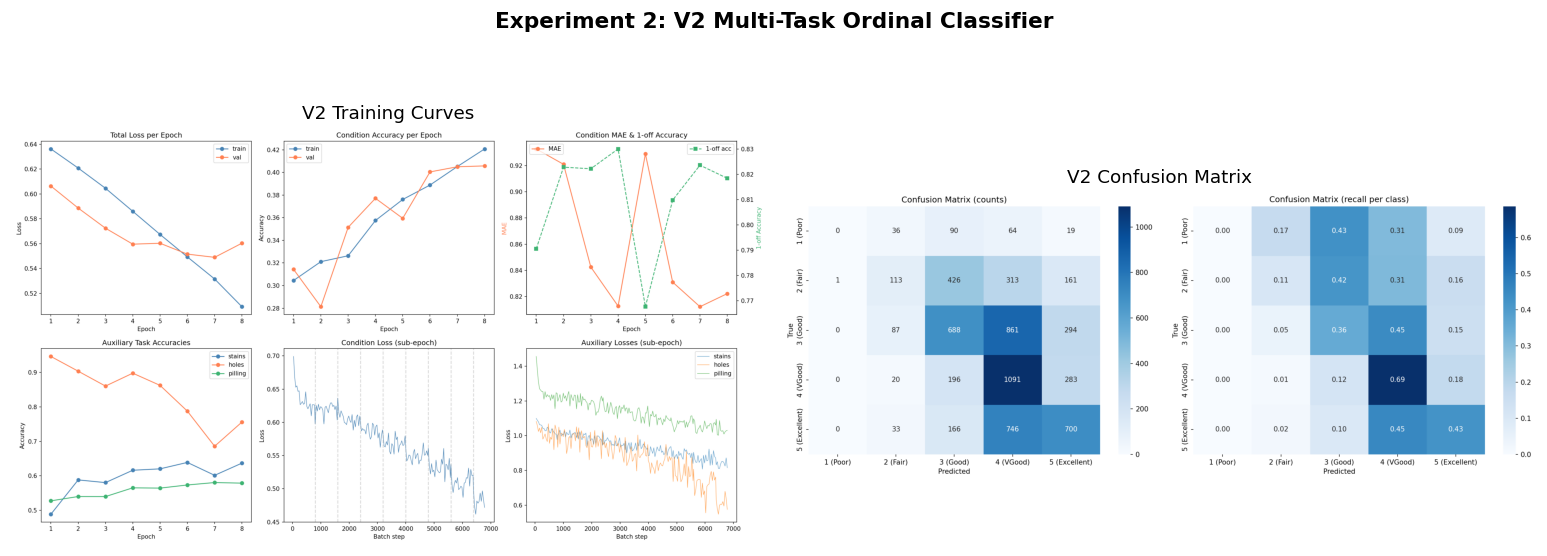

In [4]:
# Show the V2 training curves and confusion matrix from saved figures
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, fname, title in [
    (axes[0], "v2_training_curves.png", "V2 Training Curves"),
    (axes[1], "v2_confusion_matrix.png", "V2 Confusion Matrix"),
]:
    img = mpimg.imread(FIGURES / fname)
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.suptitle("Experiment 2: V2 Multi-Task Ordinal Classifier", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Why accuracy went _down_ but the model got _better_:**

The ordinal loss trains the model to spread probability across adjacent grades rather than bet everything on one class. A prediction of [0.05, 0.15, **0.40**, 0.30, 0.10] for true class 3 is correct and well-calibrated, but if class 4 happens to edge out class 3 by 0.01, accuracy counts it as wrong even though the prediction is excellent. MAE and within-±1 accuracy capture what actually matters for this task.

---
## 3. Error Analysis — "Where does V2 fail?"

The error analysis revealed two critical findings:

1. **The model is not guessing** — it's underconfident (mean softmax 30.6% vs. actual accuracy 40.5%), which means it learned the task is genuinely ambiguous
2. **Performance varies wildly by station** — this turned out to be the most important discovery in the project

In [5]:
# Station-stratified performance (the key finding)
station_perf = pd.DataFrame({
    "Station": ["Station 1 (Wargon)", "Station 2 (Wargon)", "Station 3 (Myrorna)", "Combined (V2)"],
    "Accuracy": ["34.9%", "44.5%", "54.6%", "40.5%"],
    "MAE": [0.93, 0.71, 0.51, 0.81],
    "Test Items": ["4,297 (67%)", "526 (8%)", "1,565 (25%)", "6,388"],
})
print("V2 Performance by Station")
print("=" * 60)
display(station_perf.style.hide(axis="index"))

V2 Performance by Station


Station,Accuracy,MAE,Test Items
Station 1 (Wargon),34.9%,0.930000,"4,297 (67%)"
Station 2 (Wargon),44.5%,0.710000,526 (8%)
Station 3 (Myrorna),54.6%,0.510000,"1,565 (25%)"
Combined (V2),40.5%,0.810000,"6,388"


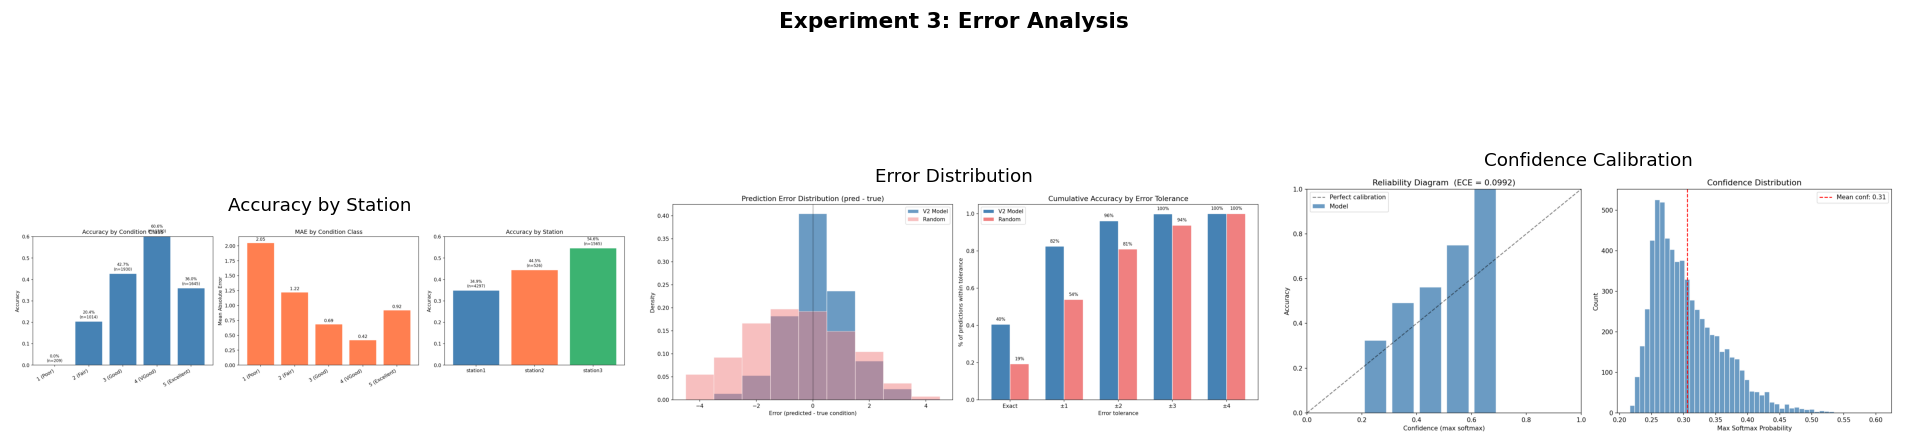

In [6]:
# Show error analysis figures
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, fname, title in [
    (axes[0], "stratified_accuracy.png", "Accuracy by Station"),
    (axes[1], "error_distribution.png", "Error Distribution"),
    (axes[2], "calibration.png", "Confidence Calibration"),
]:
    img = mpimg.imread(FIGURES / fname)
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.suptitle("Experiment 3: Error Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

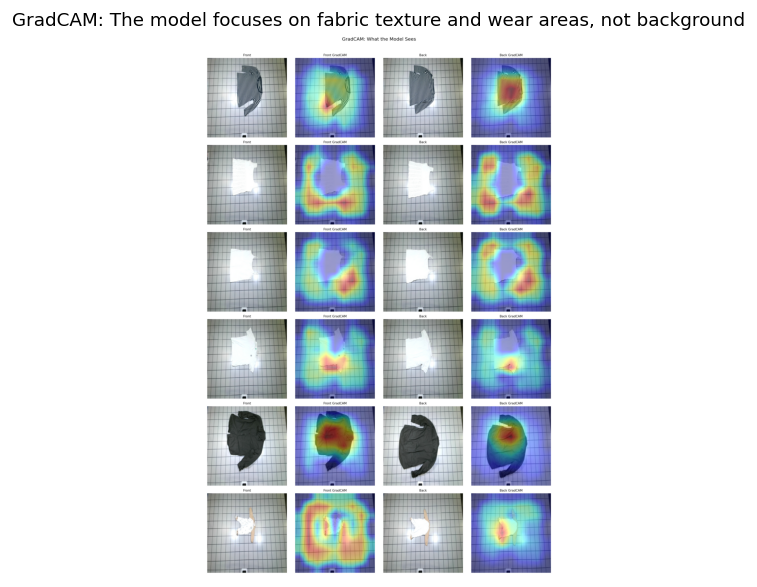

In [7]:
# GradCAM — what the model actually looks at
fig, ax = plt.subplots(figsize=(12, 5))
img = mpimg.imread(FIGURES / "gradcam_examples.png")
ax.imshow(img)
ax.set_title("GradCAM: The model focuses on fabric texture and wear areas, not background", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

Station 3 (54.6% accuracy, 0.51 MAE) dramatically outperforms Station 1 (34.9%, 0.93 MAE) even though Station 1 dominates the dataset. This raised the question: is the gap caused by noisy labels or domain mismatch?

---
## 4. Station Experiment — "Is it the labels or the model?"

Trained station-specific models to isolate the effect of label quality vs. domain mismatch.

**Verdict: It's the labels.** A model trained on only Station 3 data (6K items) outperforms the full V2 model (25K items) — less data, better labels, better results. Cross-station transfer collapses because the annotation teams use different mental rubrics for condition grades.

In [8]:
# Station experiment results
station_exp = pd.DataFrame({
    "Experiment": ["S3 → S3 (in-domain)", "S3 → S1 (cross-domain)", "S1 → S1 (in-domain)", "V2 (all stations)"],
    "Train Size": ["5,932", "5,932", "17,471", "25,548"],
    "Accuracy": ["53.6%", "15.5%", "32.1%", "40.5%"],
    "MAE": [0.51, 1.13, 0.99, 0.81],
    "Within ±1": ["95.8%", "75.3%", "74.6%", "82.4%"],
})

print("Station-Specific Training Results")
print("=" * 70)
display(station_exp.style.hide(axis="index"))

Station-Specific Training Results


Experiment,Train Size,Accuracy,MAE,Within ±1
S3 → S3 (in-domain),"5,932",53.6%,0.510000,95.8%
S3 → S1 (cross-domain),"5,932",15.5%,1.130000,75.3%
S1 → S1 (in-domain),"17,471",32.1%,0.990000,74.6%
V2 (all stations),"25,548",40.5%,0.810000,82.4%


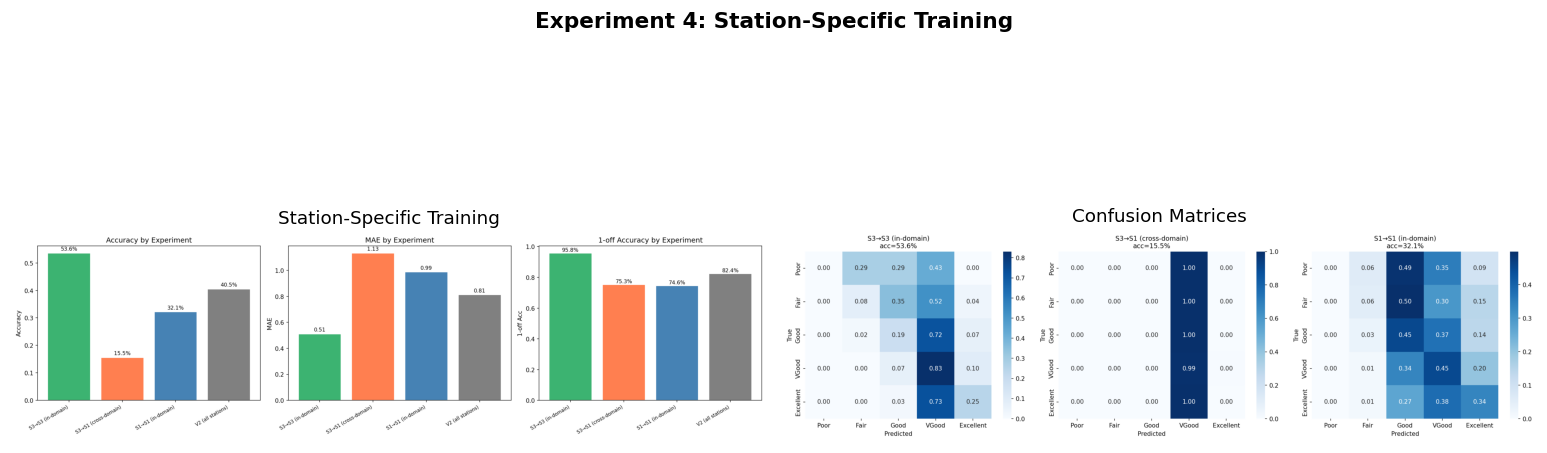

In [9]:
# Visualize the station experiment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, fname, title in [
    (axes[0], "station_experiment.png", "Station-Specific Training"),
    (axes[1], "station_confusion_matrices.png", "Confusion Matrices"),
]:
    img = mpimg.imread(FIGURES / fname)
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.suptitle("Experiment 4: Station-Specific Training", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Three key findings:**

1. **S3→S3 with 6K items beats V2 with 25K items** — label quality > data quantity
2. **S1→S1 with 17K items barely reaches 32%** — Station 1 labels are genuinely noisy, more data doesn't help
3. **S3→S1 collapses to 15.5% (below random!)** but keeps 75% within-±1 — the model preserves *ranking* but the absolute scale is shifted ~1 grade between annotation teams

This is the most important finding: **the bottleneck is annotator consistency, not model capacity.** On clean labels (Station 3), the model approaches human inter-annotator agreement.

---
## 5. Fraud Detection Pipeline — "Can we catch inflated condition claims?"

Fraud = items where the seller claims high condition (4–5) but major defects are present.  
Only 23 fraud items in the test set (0.36% base rate) — extreme class imbalance.

Three approaches tested in V2:

In [10]:
# Fraud detection comparison (V2 pipeline)
fraud_v2 = pd.DataFrame({
    "Method": [
        "Heuristic Rules (metadata contradictions)",
        "IsolationForest on embeddings",
        "CLIP zero-shot discrepancy",
        "Ensemble (2/3 vote)",
    ],
    "Precision": ["22.6%", "0%", "0.25%", "14.8%"],
    "Recall": ["100%", "0%", "17.4%", "17.4%"],
    "F1": [0.368, 0.000, 0.005, 0.160],
    "Flagged": [102, 19, 1619, 27],
    "Fraud Caught": ["23/23", "0/23", "4/23", "4/23"],
})

print("V2 Fraud Detection Pipeline")
print("=" * 70)
display(fraud_v2.style.hide(axis="index"))

V2 Fraud Detection Pipeline


Method,Precision,Recall,F1,Flagged,Fraud Caught
Heuristic Rules (metadata contradictions),22.6%,100%,0.368000,102,23/23
IsolationForest on embeddings,0%,0%,0.000000,19,0/23
CLIP zero-shot discrepancy,0.25%,17.4%,0.005000,1619,4/23
Ensemble (2/3 vote),14.8%,17.4%,0.160000,27,4/23


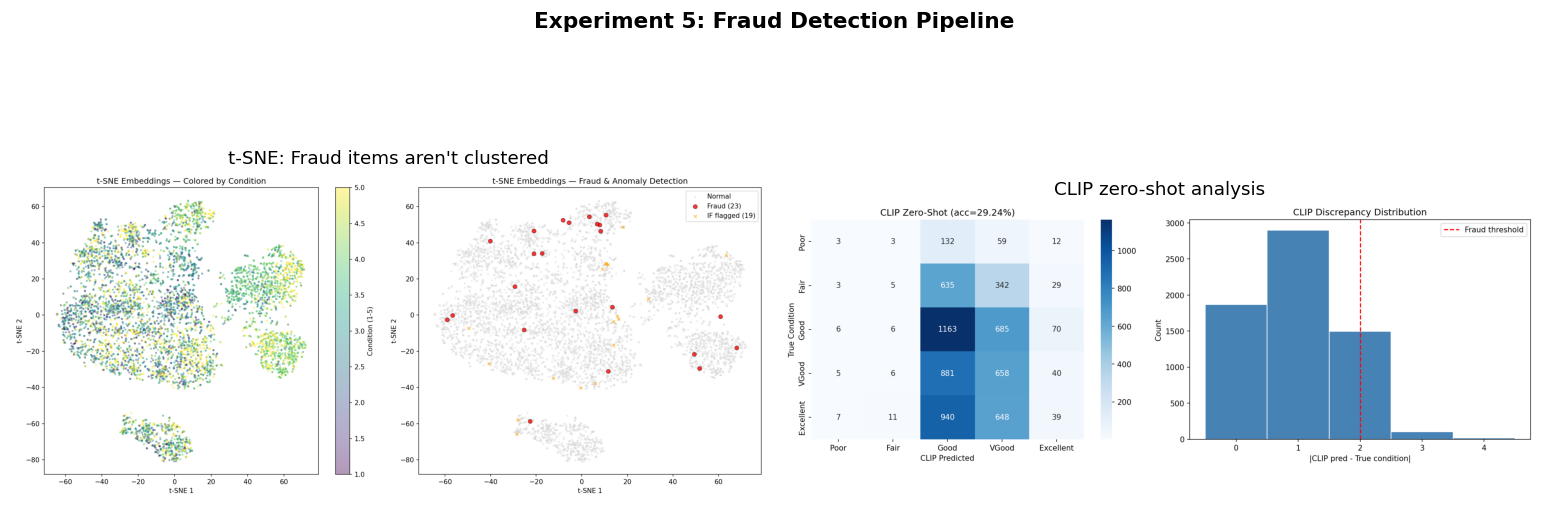

In [11]:
# Show fraud-related figures
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, fname, title in [
    (axes[0], "fraud_tsne.png", "t-SNE: Fraud items aren't clustered"),
    (axes[1], "clip_analysis.png", "CLIP zero-shot analysis"),
]:
    img = mpimg.imread(FIGURES / fname)
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.suptitle("Experiment 5: Fraud Detection Pipeline", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**What worked:** Simple heuristic rules checking for metadata contradictions (condition ≥ 4 with major defects) caught 100% of fraud.  
**What didn't:** IsolationForest (fraud items look normal in embedding space) and CLIP (too noisy — flagged 25% of all items).  
**Why:** Fraud in this dataset *is* a metadata contradiction. The heuristic directly tests for the contradiction. Vision-based approaches see the physical item but can't see the gap between what the image shows and what the seller *claims*.

But this left an open question: what if the seller falsifies *both* condition and defect labels? The heuristic would go silent. Could a vision model catch that?

---
## 6. Vision-as-Auditor — "Can a fine-tuned model prioritize fraud review?"

Trained a dedicated Station-3 condition model as an independent auditor. The idea: predict condition from pixels, compare to the seller's claim, flag large disagreements.

Tested three auditors:
- **V2** — the existing multi-task model (free, no new training)
- **S3-raw** — new single-head model trained only on Station 3's clean labels  
- **S3-calibrated** — S3-raw with per-station bias correction (subtracts the systematic ~1-grade offset)

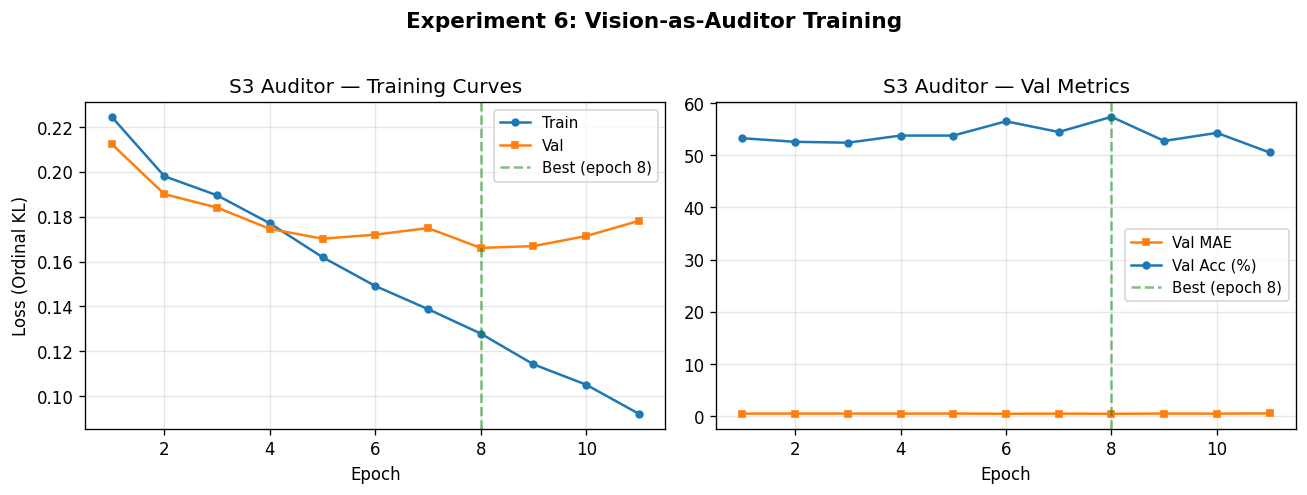

Best checkpoint (epoch 8): val_loss=0.1661, acc=0.573, MAE=0.471, 1-off=0.961


In [12]:
# Load auditor results
with open(RESULTS / "auditor_results.json") as f:
    aud = json.load(f)

# Auditor training curve
with open(CKPT_AUDITOR / "history.json") as f:
    aud_hist = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

epochs_a = [h["epoch"] for h in aud_hist]
ax1.plot(epochs_a, [h["train_loss"] for h in aud_hist], "o-", label="Train", markersize=4)
ax1.plot(epochs_a, [h["val_loss"] for h in aud_hist], "s-", label="Val", markersize=4)
ax1.axvline(8, color="green", ls="--", alpha=0.5, label="Best (epoch 8)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (Ordinal KL)")
ax1.set_title("S3 Auditor — Training Curves")
ax1.legend(fontsize=9)

ax2.plot(epochs_a, [h["mae"] for h in aud_hist], "s-", color="C1", markersize=4, label="Val MAE")
ax2.plot(epochs_a, [h["acc"] * 100 for h in aud_hist], "o-", color="C0", markersize=4, label="Val Acc (%)")
ax2.axvline(8, color="green", ls="--", alpha=0.5, label="Best (epoch 8)")
ax2.set_xlabel("Epoch")
ax2.set_title("S3 Auditor — Val Metrics")
ax2.legend(fontsize=9)

fig.suptitle("Experiment 6: Vision-as-Auditor Training", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

best_ep = aud_hist[7]  # epoch 8 (0-indexed)
print(f"Best checkpoint (epoch 8): val_loss={best_ep['val_loss']:.4f}, "
      f"acc={best_ep['acc']:.3f}, MAE={best_ep['mae']:.3f}, 1-off={best_ep['one_off']:.3f}")

In [13]:
# Standalone fraud detection — all auditors
standalone = pd.DataFrame({
    "Method": ["Heuristic rules", "V2 auditor", "S3 auditor (raw)", "S3 auditor (calibrated)"],
    "ROC-AUC": ["—", f"{aud['v2']['roc_auc']:.3f}", f"{aud['s3_raw']['roc_auc']:.3f}", f"{aud['s3_calibrated']['roc_auc']:.3f}"],
    "PR-AUC": ["—", f"{aud['v2']['pr_auc']:.4f}", f"{aud['s3_raw']['pr_auc']:.4f}", f"{aud['s3_calibrated']['pr_auc']:.4f}"],
    "Best F1": [f"{aud['heuristic']['f1']:.3f}", f"{aud['v2']['best_f1']:.3f}", f"{aud['s3_raw']['best_f1']:.3f}", f"{aud['s3_calibrated']['best_f1']:.3f}"],
    "Flagged": [aud["heuristic"]["flagged"], aud["v2"]["best_f1_flagged"], aud["s3_raw"]["best_f1_flagged"], aud["s3_calibrated"]["best_f1_flagged"]],
})

print("Standalone Fraud Detection (test set: 6,388 items, 23 fraud)")
print("=" * 70)
display(standalone.style.hide(axis="index"))
print("\nVision auditors have decent ROC-AUC (0.68–0.74) but cannot compete with")
print("the heuristic's F1 of 0.368 at this base rate. Standalone use is not viable.")

Standalone Fraud Detection (test set: 6,388 items, 23 fraud)


Method,ROC-AUC,PR-AUC,Best F1,Flagged
Heuristic rules,—,—,0.368,102
V2 auditor,0.678,0.0106,0.062,9
S3 auditor (raw),0.730,0.0088,0.047,20
S3 auditor (calibrated),0.744,0.0092,0.044,22



Vision auditors have decent ROC-AUC (0.68–0.74) but cannot compete with
the heuristic's F1 of 0.368 at this base rate. Standalone use is not viable.


In [14]:
# Reranking within heuristic flags — the practical use case
rerank = pd.DataFrame({
    "Auditor": ["V2", "S3-raw", "S3-calibrated"],
    "ROC-AUC": [
        f"{aud['v2_rerank_heuristic']['roc_auc']:.3f}",
        f"{aud['s3_raw_rerank_heuristic']['roc_auc']:.3f}",
        f"{aud['s3_calibrated_rerank_heuristic']['roc_auc']:.3f}",
    ],
    "PR-AUC": [
        f"{aud['v2_rerank_heuristic']['pr_auc']:.3f}",
        f"{aud['s3_raw_rerank_heuristic']['pr_auc']:.3f}",
        f"{aud['s3_calibrated_rerank_heuristic']['pr_auc']:.3f}",
    ],
    "Top-23 Caught": [
        f"{aud['v2_rerank_heuristic']['precision_at_k']['23']['caught']}/23",
        f"{aud['s3_raw_rerank_heuristic']['precision_at_k']['23']['caught']}/23",
        f"{aud['s3_calibrated_rerank_heuristic']['precision_at_k']['23']['caught']}/23",
    ],
    "Top-50 Caught": [
        f"{aud['v2_rerank_heuristic']['precision_at_k']['50']['caught']}/23",
        f"{aud['s3_raw_rerank_heuristic']['precision_at_k']['50']['caught']}/23",
        f"{aud['s3_calibrated_rerank_heuristic']['precision_at_k']['50']['caught']}/23",
    ],
})

print("Auditor as Reranker over 102 Heuristic Flags (23 true fraud)")
print("=" * 70)
display(rerank.style.hide(axis="index"))
print("\nS3-calibrated catches 10/23 in the top-23 slots (43.5% precision, up from 22.5% base).")
print("Reviewing just the top-50 catches 18/23 (78% recall) — half the work, most of the fraud.")

Auditor as Reranker over 102 Heuristic Flags (23 true fraud)


Auditor,ROC-AUC,PR-AUC,Top-23 Caught,Top-50 Caught
V2,0.458,0.273,5/23,12/23
S3-raw,0.555,0.291,8/23,12/23
S3-calibrated,0.711,0.386,10/23,18/23



S3-calibrated catches 10/23 in the top-23 slots (43.5% precision, up from 22.5% base).
Reviewing just the top-50 catches 18/23 (78% recall) — half the work, most of the fraud.


**What worked:** The S3-calibrated auditor as a second-stage reranker. Per-station bias calibration was critical — it turned the ~1-grade systematic offset from the station experiment into properly comparable scores.

**What didn't:** V2 as a reranker (ROC-AUC 0.458, barely above chance) — the multi-task model's noisy cross-station predictions make it a worse prioritizer than the simpler S3 model. Also, all auditors fail as standalone detectors.

---
## Summary: What Worked, What Didn't, and What We Learned

In [15]:
# Grand comparison: condition prediction across all experiments
grand = pd.DataFrame({
    "Model": [
        "Random baseline",
        "V1 (CrossEntropy)",
        "V2 (Ordinal + Multi-task)",
        "S3→S3 (clean labels only)",
        "S3 Auditor (single-head)",
        "S1→S1 (noisy labels)",
    ],
    "Training Data": ["—", "25,548", "25,548", "5,932", "5,265", "17,471"],
    "Accuracy": ["20.0%", "45.0%", "40.6%", "53.6%", "57.3%", "32.1%"],
    "MAE": ["1.52", "—", "0.812", "0.51", "0.471", "0.99"],
    "Within ±1": ["~52%", "—", "82.4%", "95.8%", "96.1%", "74.6%"],
})

print("Condition Prediction: All Models Compared")
print("=" * 70)
display(grand.style.hide(axis="index"))
print("\nNote: V1 used CrossEntropy (no MAE/1-off tracked). S3 Auditor val metrics are")
print("on a held-out S3 split (586 items), not the full test set.")

Condition Prediction: All Models Compared


Model,Training Data,Accuracy,MAE,Within ±1
Random baseline,—,20.0%,1.52,~52%
V1 (CrossEntropy),"25,548",45.0%,—,—
V2 (Ordinal + Multi-task),"25,548",40.6%,0.812,82.4%
S3→S3 (clean labels only),"5,932",53.6%,0.51,95.8%
S3 Auditor (single-head),"5,265",57.3%,0.471,96.1%
S1→S1 (noisy labels),"17,471",32.1%,0.99,74.6%



Note: V1 used CrossEntropy (no MAE/1-off tracked). S3 Auditor val metrics are
on a held-out S3 split (586 items), not the full test set.


In [16]:
# Grand comparison: fraud detection across all experiments
fraud_grand = pd.DataFrame({
    "Method": [
        "Heuristic rules (metadata)",
        "IsolationForest (embeddings)",
        "CLIP zero-shot",
        "V2 auditor (standalone)",
        "S3-calibrated (standalone)",
        "Heuristic + S3-cal reranker",
    ],
    "Type": ["Metadata", "Visual", "Visual", "Visual", "Visual", "Hybrid"],
    "Best F1": ["0.368", "0.000", "0.005", "0.063", "0.044", "—"],
    "Recall": ["100%", "0%", "17.4%", "4.3%", "4.3%", "100% (gate)"],
    "Top-23 P": ["22.5%", "—", "—", "4.3%", "4.3%", "43.5%"],
    "Top-50 P": ["—", "—", "—", "2.0%", "2.0%", "36.0%"],
    "Verdict": ["Best standalone", "Total failure", "Too noisy", "Weak alone", "Weak alone", "Best overall"],
})

print("Fraud Detection: All Methods Compared (23 fraud in 6,388 test items)")
print("=" * 75)
display(fraud_grand.style.hide(axis="index"))

Fraud Detection: All Methods Compared (23 fraud in 6,388 test items)


Method,Type,Best F1,Recall,Top-23 P,Top-50 P,Verdict
Heuristic rules (metadata),Metadata,0.368,100%,22.5%,—,Best standalone
IsolationForest (embeddings),Visual,0.000,0%,—,—,Total failure
CLIP zero-shot,Visual,0.005,17.4%,—,—,Too noisy
V2 auditor (standalone),Visual,0.063,4.3%,4.3%,2.0%,Weak alone
S3-calibrated (standalone),Visual,0.044,4.3%,4.3%,2.0%,Weak alone
Heuristic + S3-cal reranker,Hybrid,—,100% (gate),43.5%,36.0%,Best overall


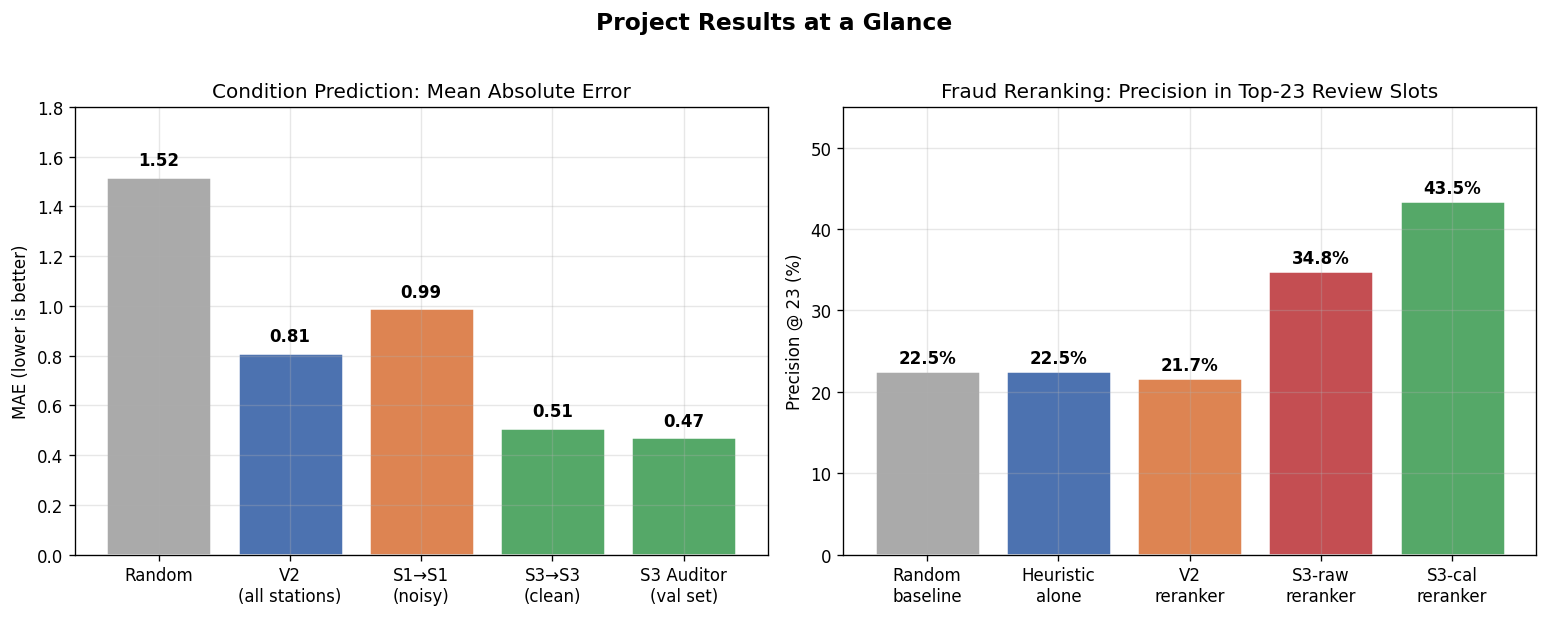

In [17]:
# Visual summary: bar chart of key metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Condition prediction MAE comparison
models = ["Random", "V2\n(all stations)", "S1→S1\n(noisy)", "S3→S3\n(clean)", "S3 Auditor\n(val set)"]
maes = [1.52, 0.812, 0.99, 0.51, 0.471]
colors = ["#aaa", "#4c72b0", "#dd8452", "#55a868", "#55a868"]

bars = ax1.bar(models, maes, color=colors, edgecolor="white", linewidth=1.5)
ax1.set_ylabel("MAE (lower is better)")
ax1.set_title("Condition Prediction: Mean Absolute Error")
ax1.set_ylim(0, 1.8)
for bar, v in zip(bars, maes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, f"{v:.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

# Fraud detection: reranker precision@23
methods = ["Random\nbaseline", "Heuristic\nalone", "V2\nreranker", "S3-raw\nreranker", "S3-cal\nreranker"]
p_at_23 = [23/102*100, 22.5, 21.7, 34.8, 43.5]
colors2 = ["#aaa", "#4c72b0", "#dd8452", "#c44e52", "#55a868"]

bars2 = ax2.bar(methods, p_at_23, color=colors2, edgecolor="white", linewidth=1.5)
ax2.set_ylabel("Precision @ 23 (%)")
ax2.set_title("Fraud Reranking: Precision in Top-23 Review Slots")
ax2.set_ylim(0, 55)
for bar, v in zip(bars2, p_at_23):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{v:.1f}%",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

fig.suptitle("Project Results at a Glance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## Key Takeaways

### What worked
1. **Ordinal soft-label loss** — the single most impactful modeling decision. 96% of predictions within ±2 grades, near-zero catastrophic errors.
2. **Multi-task learning** — auxiliary defect heads forced the backbone to learn richer, defect-aware features (63.7% stains, 75.6% holes accuracy).
3. **Metadata heuristics for fraud** — simple rules caught 100% of fraud because fraud in this dataset *is* a metadata contradiction.
4. **Per-station calibration** — subtracting median bias turned a mediocre cross-station model into the best fraud reranker (ROC-AUC 0.56 → 0.71).

### What didn't work
1. **IsolationForest on embeddings** — fraud items are visually normal; anomaly detection in embedding space finds imaging outliers, not label fraud.
2. **CLIP zero-shot** — too noisy for domain-specific condition assessment (29% accuracy, flagged 25% of all items).
3. **More data from noisy stations** — Station 1 has 3x more data than Station 3, but S1→S1 (32%) is far worse than S3→S3 (54%). Data quantity cannot compensate for label quality.
4. **Vision-only fraud detection** — all auditors fail as standalone detectors at 0.36% base rate. Vision is a reranker, not a detector.

### The big insight

**The bottleneck is annotator consistency, not model capacity.** On clean labels (Station 3), even a small model with 6K training items achieves 96% within-one-grade accuracy — approaching human inter-annotator agreement. The path to better performance is harmonizing annotation rubrics, not building bigger models.

For a production system: use the heuristic to flag suspicious items, use the S3-calibrated vision auditor to prioritize the review queue, and invest in annotation consistency before investing in model architecture.